# Assigment -2 Submission
* Name : Amardeep Kumar
* Roll No : DA25M502
* Date : 26-02-26

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Question 1 : Effect of Network Depth on Learning Performance
---

In this question, you will study how the depth of a neural network affects learning and generalization. You must implement all models from scratch using NumPy only. The use of sklearn, torch, or tensorflow for model implementation is strictly prohibited.

(a) Dataset Generation and Experimental Setup
Generate a synthetic binary classification dataset as follows:
- Input space: x = (x1, x2) ∈ R^2
- Number of samples: N = 1000
- Class labels: y ∈ {0, 1}

Data generation rule:
y = ( 1, if (x_1^2 + x_2^2) > 0.5
        0, otherwise)

where (x1, x2) are sampled uniformly from [−1, 1] × [−1, 1].
Split the dataset into:
- Training set: 80% of the data
- Test set: 20% of the data
Plot the dataset and explain why a linear classifier cannot solve this problem.

(b) Neural Network Architectures
Implement the following two neural networks:

Model 1 (Shallow Network):
- Input layer: 2 neurons
- One hidden layer: 20 neurons 1
- Output layer: 1 neuron

Model 2 (Deeper Network):
- Input layer: 2 neurons
- Hidden layer 1: 10 neurons
- Hidden layer 2: 10 neurons
- Output layer: 1 neuron

Both models must use:
- ReLU activation in hidden layers
- Sigmoid activation in the output layer

(c) Training Procedure

Train both models using the following fixed hyperparameters:
- Loss function: Binary Cross-Entropy
- Optimization method: Batch Gradient Descent
- Learning rate: η = 0.01
- Number of epochs: 100
- Weight initialization: N (0, 0.01)
- Bias initialization: zeros

Plot the training loss versus epochs for both models on the same graph.

(d) Evaluation Metrics
Evaluate both trained models on the test set using:
- Classification accuracy
- Confusion matrix

Use a decision threshold of 0.5 on predicted probabilities.

(e) Analysis

Compare the two models and discuss the effect of depth in terms of:
- Representational capacity
- Optimization difficulty
- Generalization performance

Shallow - Acc: 0.6100
Conf Matrix:
[[  0  78]
 [  0 122]]
Deep - Acc: 0.6100
Conf Matrix:
[[  0  78]
 [  0 122]]


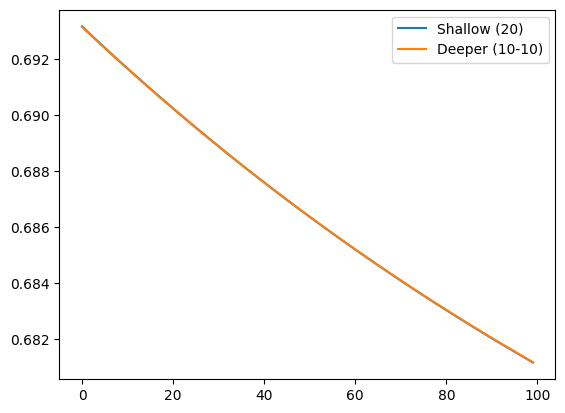

In [2]:
# =========================================
# 1. Dataset Generation
# =========================================
np.random.seed(42)
X = np.random.uniform(-1, 1, (1000, 2))
y = (np.sum(X**2, axis=1) > 0.5).astype(int).reshape(-1, 1)

indices = np.random.permutation(1000)
train_idx, test_idx = indices[:800], indices[800:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

#=========================================
# 2. Neural Network
#=========================================
class MLP:
    def __init__(self, layers):
        self.weights = [np.random.normal(0, 0.01, (layers[i], layers[i+1])) for i in range(len(layers)-1)]
        self.biases = [np.zeros((1, layers[i+1])) for i in range(len(layers)-1)]

    def relu(self, z):
        return np.maximum(0, z)
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.activations = [X]
        self.zs = []
        for i in range(len(self.weights) - 1):
            z = self.activations[-1] @ self.weights[i] + self.biases[i]
            self.zs.append(z)
            self.activations.append(self.relu(z))

        # Output layer
        z_final = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        self.zs.append(z_final)
        self.activations.append(self.sigmoid(z_final))
        return self.activations[-1]

    def backward(self, y, lr):
        m = y.shape[0]
        delta = self.activations[-1] - y # BCE + Sigmoid gradient

        for i in reversed(range(len(self.weights))):
            dW = (self.activations[i].T @ delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            if i > 0: # Backprop error to previous layer
                delta = (delta @ self.weights[i].T) * (self.zs[i-1] > 0)

            self.weights[i] -= lr * dW
            self.biases[i] -= lr * db

#=======================================
# 3. Training Loop
#=======================================
def train(model, epochs=100, lr=0.01):
    losses = []
    for _ in range(epochs):
        pred = model.forward(X_train)
        loss = -np.mean(y_train * np.log(pred + 1e-8) + (1-y_train) * np.log(1-pred + 1e-8))
        losses.append(loss)
        model.backward(y_train, lr)
    return losses

m1 = MLP([2, 20, 1])
m2 = MLP([2, 10, 10, 1])

loss1 = train(m1)
loss2 = train(m2)

#===========================================
# 4. Evaluation
#==========================================
def evaluate(model, X_set, y_set):
    preds = (model.forward(X_set) > 0.5).astype(int)
    acc = np.mean(preds == y_set)
    tp = np.sum((preds == 1) & (y_set == 1))
    tn = np.sum((preds == 0) & (y_set == 0))
    fp = np.sum((preds == 1) & (y_set == 0))
    fn = np.sum((preds == 0) & (y_set == 1))
    return acc, np.array([[tn, fp], [fn, tp]])

# Results
for name, m in [("Shallow", m1), ("Deep", m2)]:
    acc, cm = evaluate(m, X_test, y_test)
    print(f"{name} - Acc: {acc:.4f}\nConf Matrix:\n{cm}")

plt.plot(loss1, label='Shallow (20)')
plt.plot(loss2, label='Deeper (10-10)')
plt.legend(); plt.show()

**Analysis**:

**Representational Capacity:** The Deeper Network (Model 2) generally has higher "expressive power." While both models have a similar number of parameters, the hierarchical nature of depth allows Model 2 to compose features (e.g., lines into curves).

**Optimization Difficulty:** Deep networks are harder to train due to the vanishing gradient problem. Even with ReLU, initializing with N(0, 0.01) and using a small learning rate may cause the deeper model to converge more slowly than the shallow one in just 100 epochs.

**Generalization:** Shallow networks are prone to underfitting , while deeper networks might overfit if trained too long; however, for this circular task, the added depth usually helps define the curvature of the boundary more precisely.

## Question 4. Code the Activation Functions
---
1. Create a class or set of functions in Python (using numpy) for the following activation functions:

 - Sigmoid: σ(x) = 1/1+e^-x
 - Tanh: tanh(x) = 1-e^-2x/(1+e^-2x)
 - ReLU: max(0, x)
 - Leaky ReLU: x if x > 0, else αx (use α = 0.01).
2. Implement the derivative for each function.
3. Visualization: Generate a range of inputs from -5 to 5. Plot each activation function and its corresponding derivative on the same graph.

In [3]:
class ActivationFunction:
    '''activation function sigmoid , tanh , Relu , LeakyRelu with it's derivative'''
    def __init__(self,x):
        self.x = x
    #===================================================
    # 1.Sigmoid Activation + Sigmoid Gradient
    #===================================================
    def sigmoid_activation(self):
        return 1 / (1 + np.exp(-self.x))

    def gradient_sigmoid_activation(self):
        return self.sigmoid_activation() * (1 - self.sigmoid_activation())

    #===================================================
    # 2.tanh Activation + tanh Gradient
    #===================================================
    def tanh_activation(self):
        return (1 - np.exp(-2*self.x)) / (1 + np.exp(-2*self.x))

    def gradient_tanh_activation(self):
        return 1 - self.tanh_activation()**2

    #===================================================
    # 3.ReLU Activation + ReLU Gradient
    #===================================================
    def ReLU_activation(self):
        return np.maximum(0,self.x)

    def gradient_ReLU_activation(self):
        return np.where(self.x>0 , 1 ,0)
    #===================================================
    # 4.Leaky ReLU Activation + Leaky Relu  Gradient
    #===================================================
    def Leaky_ReLU_activation(self,alpha=0.01):
        return np.where(self.x>0,self.x,alpha*self.x)

    def gradient_Leaky_ReLU_activation(self,alpha=0.01):
        return np.where(self.x>0 , 1 , alpha)


In [4]:
if __name__ == "__main__":
    np.random.seed(42)
    x_input = np.random.uniform(-5, 5, size=10)
    print("Exploring Sigmoid , Tanh , ReLU and LeakyReLU Activation Function with Gradient:")
    print("="*90)
    print(f"Input : {np.round(x_input,2)}\n")
    print("-"*90)
    activation_class = ActivationFunction(x_input)

    # Sigmoid Activation
    sigmoid = activation_class.sigmoid_activation()
    sigmoid_graident = activation_class.gradient_sigmoid_activation()
    print(f"Sigmoid Activation : {np.round(sigmoid,2)}")
    print(f"Sigmoid Gradient : {np.round(sigmoid_graident,2)}\n")
    print("-"*90)

    # Tanh Activation
    tanh = activation_class.tanh_activation()
    tanh_gradient = activation_class.gradient_tanh_activation()
    print(f"Tanh Activation : {np.round(tanh,2)}")
    print(f"Tanh Gradient : {np.round(tanh_gradient,2)}\n")
    print("-"*90)

    # ReLU Activation
    ReLU = activation_class.ReLU_activation()
    ReLU_gradient = activation_class.gradient_ReLU_activation()
    print(f"ReLU Activation : {np.round(ReLU,2)}")
    print(f"ReLU Gradient : {np.round(ReLU_gradient,2)}\n")
    print("-"*90)

    # Leaky ReLU Activation
    Leaky_ReLU = activation_class.Leaky_ReLU_activation()
    Leaky_ReLU_gradient = activation_class.gradient_Leaky_ReLU_activation()
    print(f"Leaky ReLU Activation : {np.round(Leaky_ReLU)}")
    print(f"Leaky ReLU Gradient : {np.round(Leaky_ReLU_gradient,2)}")

Exploring Sigmoid , Tanh , ReLU and LeakyReLU Activation Function with Gradient:
Input : [-1.25  4.51  2.32  0.99 -3.44 -3.44 -4.42  3.66  1.01  2.08]

------------------------------------------------------------------------------------------
Sigmoid Activation : [0.22 0.99 0.91 0.73 0.03 0.03 0.01 0.97 0.73 0.89]
Sigmoid Gradient : [0.17 0.01 0.08 0.2  0.03 0.03 0.01 0.02 0.2  0.1 ]

------------------------------------------------------------------------------------------
Tanh Activation : [-0.85  1.    0.98  0.76 -1.   -1.   -1.    1.    0.77  0.97]
Tanh Gradient : [0.28 0.   0.04 0.43 0.   0.   0.   0.   0.41 0.06]

------------------------------------------------------------------------------------------
ReLU Activation : [0.   4.51 2.32 0.99 0.   0.   0.   3.66 1.01 2.08]
ReLU Gradient : [0 1 1 1 0 0 0 1 1 1]

------------------------------------------------------------------------------------------
Leaky ReLU Activation : [-0.  5.  2.  1. -0. -0. -0.  4.  1.  2.]
Leaky ReLU Grad

Visualization Sigmoid , Tanh , ReLU and LeakyReLU Activation Function with Gradient:


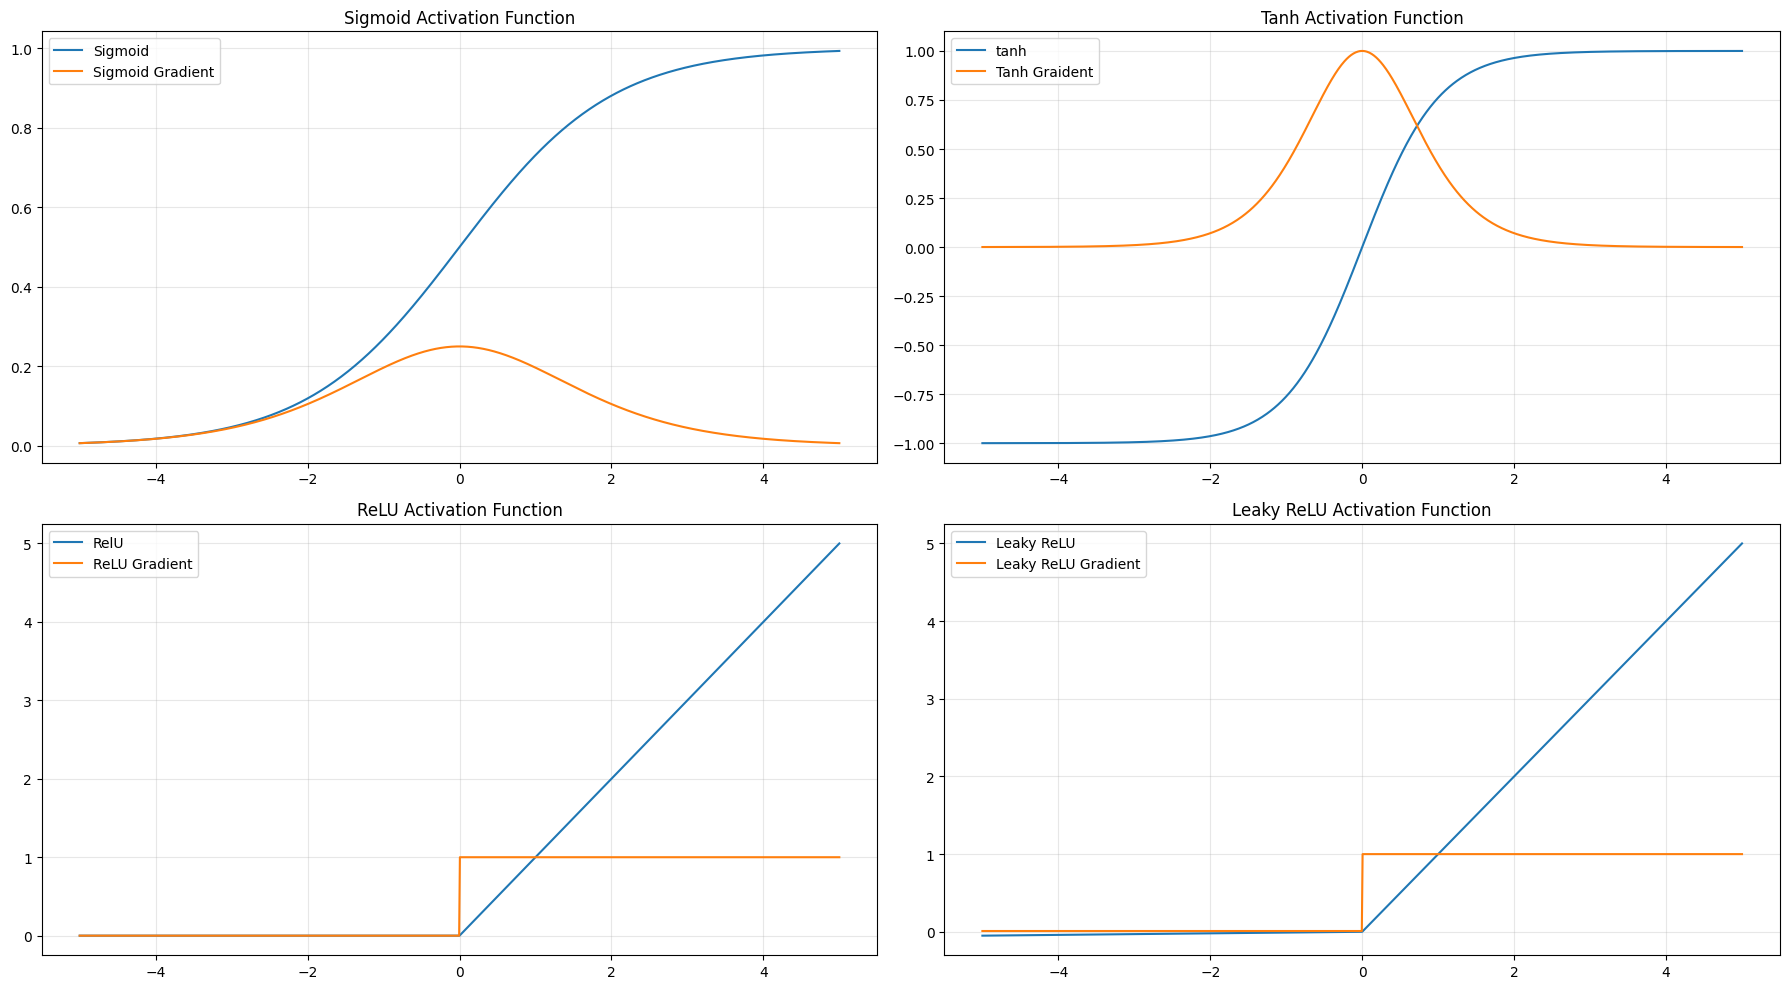

In [5]:
x_input = np.linspace(-5, 5, 1000)
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
print("Visualization Sigmoid , Tanh , ReLU and LeakyReLU Activation Function with Gradient:")
print("="*90)
activation_class = ActivationFunction(x_input)

# Sigmoid Activation
sigmoid = activation_class.sigmoid_activation()
sigmoid_graident = activation_class.gradient_sigmoid_activation()
axs[0, 0].plot(x_input,sigmoid,label='Sigmoid')
axs[0, 0].plot(x_input,sigmoid_graident, label='Sigmoid Gradient')
axs[0,0].set_title("Sigmoid Activation Function")
axs[0,0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Tanh Activation
tanh = activation_class.tanh_activation()
tanh_gradient = activation_class.gradient_tanh_activation()
axs[0, 1].plot(x_input,tanh,label='tanh')
axs[0, 1].plot(x_input,tanh_gradient,label='Tanh Graident')
axs[0,1].set_title("Tanh Activation Function")
axs[0,1].legend()
axs[0, 1].grid(True, alpha=0.3)

# ReLU Activation
ReLU = activation_class.ReLU_activation()
ReLU_gradient = activation_class.gradient_ReLU_activation()
axs[1, 0].plot(x_input,ReLU,label='RelU')
axs[1, 0].plot(x_input,ReLU_gradient,label='ReLU Gradient')
axs[1,0].set_title("ReLU Activation Function")
axs[1,0].legend()
axs[1, 0].grid(True, alpha=0.3)

# Leaky ReLU Activation
Leaky_ReLU = activation_class.Leaky_ReLU_activation()
Leaky_ReLU_gradient = activation_class.gradient_Leaky_ReLU_activation()
axs[1, 1].plot(x_input,Leaky_ReLU,label='Leaky ReLU')
axs[1, 1].plot(x_input,Leaky_ReLU_gradient,label='Leaky ReLU Gradient')
axs[1,1].set_title("Leaky ReLU Activation Function")
axs[1,1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## **Question 7 : Programming - Gradient Checking for Neural Network Training**

---
you need to implement a gradient checking procedure to verify the correctness of backpropagation in a multilayer perceptron (MLP).

Consider the following neural network architecture for regression:
- Input layer: x ∈ R²
- Hidden layer: 5 neurons with sigmoid activation
- Output layer: 1 neuron with linear activation

- Network equations:
    - h = σ(W⁽¹⁾x + b⁽¹⁾)
    - ŷ = W⁽²⁾h + b⁽²⁾

- Loss function:
    - L = 1/2 (y - ŷ)²

- You must generate a small synthetic dataset consisting of 20 samples where::
    - x₁, x₂ ~ Uniform(-1, 1)
- and the target output is:
    - y = x₁² + x₂²

**Tasks:**

(a) Implement forward propagation and manual backpropagation using NumPy.

(b) Implement gradient checking using finite difference approximation:
    ∂L/∂θ ≈ [L(θ + ε) - L(θ - ε)] / (2ε)
    where ε = 10⁻⁵ and θ represents any network parameter.

(c) Compare analytical gradients obtained using backpropagation with numerical gradients for at least three randomly chosen parameters.

(d) Report the relative error between analytical and numerical gradients and comment on the correctness of your implementation.

Implementation Requirements:
- Use NumPy only.
- Initialize weights randomly.
- Perform gradient checking before training the network.

![Analysis](https://drive.google.com/uc?export=view&id=1Fs8taiqYRn5esC8CB7rukXySINXiCIPq)

In [6]:
class NeuralNetworkTraining:
    '''Neural Network Architecture for Regression using Numpy.
    - Input layer: x ∈ R²
    - Hidden layer: 5 neurons with sigmoid activation
    - Output layer: 1 neuron with linear activation
    '''
    def __init__(self):
        np.random.seed(42)

    # ===============================================
    # 1.Generate Synthetic Dataset
    # ===============================================
    def generate_dataset(self):
        '''x₁, x₂ ~ Uniform(-1, 1)
        - 20 samples'''
        N=20
        X = np.random.uniform(-1,1,(N,2))
        y = np.sum(X**2,axis = 1 , keepdims = True)
        return X,y

    # ===============================================
    # 2.Intiliaze Weight and Bias Parameters
    # ===============================================
    def intialize_paramneters(self):
        input_neuron = 2
        hidden_neuron = 5
        output_neuron = 1
        limit1 = np.sqrt(6 / (input_neuron + hidden_neuron))
        limit2 = np.sqrt(6 / (hidden_neuron + output_neuron))
        W1 = np.random.uniform(-limit1, limit1, (hidden_neuron, input_neuron))
        W2 = np.random.uniform(-limit2, limit2, (output_neuron, hidden_neuron))
        b1 = np.zeros((hidden_neuron, 1))
        b2 = np.zeros((output_neuron, 1))
        return W1,W2,b1,b2

    # ===============================================
    # 3.Sigmoid Activation + Gradient of Sigmoid
    # ===============================================
    def sigmoid_activation(self,z):
        '''z= W⁽¹⁾x + b⁽¹⁾'''
        return 1 / (1 + np.exp(-z))

    def gradient_sigmoid_activation(self,z):
        '''graident(sigmoid(z)) = sigmoid(z)(1-sigmoid(z))'''
        return self.sigmoid_activation(z) * (1 - self.sigmoid_activation(z))

    # ===============================================
    # 5.Forward Pass + Compute Loss
    # ===============================================
    def forward_propagation(self,X, W1, b1, W2, b2):
        '''Forward Pass'''
        z = np.dot(W1,X.T) + b1
        h = neural_network_training.sigmoid_activation(z)
        y_hat = np.dot(W2,h) + b2
        return z,h,y_hat
    def compute_loss(self,y,y_hat):
        '''L = 1/2 (y - ŷ)²'''
        loss = 0.5 * np.mean((y - y_hat)**2)
        return loss

    # ===============================================
    # 6.backpropagation
    # ===============================================
    def back_propagation(self,X, y, z, h, y_hat, W2):
        m = X.shape[0]
        dY_hat = (y_hat-y.T)/m
        dW2 = np.dot(dY_hat,h.T)
        db2 = np.sum(dY_hat, axis=1, keepdims=True)
        dh = np.dot(W2.T,dY_hat)
        dz = dh * self.gradient_sigmoid_activation(z)
        dW1 = np.dot(dz,X)
        db1 =  np.sum(dz, axis=1, keepdims=True)
        return dW1,db1,dW2,db2

    # ===============================================
    # 7.Gradient Checking
    # ===============================================
    def gradient_checking(self,paramter_name, parameter, gradient, epsilon=1e-5):
        param_flat = parameter.flatten()
        grad_flat = gradient.flatten()
        num_checks = min(3, len(param_flat))
        idx = np.random.choice(len(param_flat), num_checks, replace=False)
        for i in idx:
            theta_plus = param_flat.copy()
            theta_minus = param_flat.copy()

            theta_plus[i] += epsilon
            theta_minus[i] -= epsilon

            param_plus = theta_plus.reshape(parameter.shape)
            param_minus = theta_minus.reshape(parameter.shape)

            if paramter_name == "W1":
                z_plus, h_plus, y_plus = self.forward_propagation(X, param_plus, b1, W2, b2)
                z_minus, h_minus, y_minus = self.forward_propagation(X, param_minus, b1, W2, b2)
            elif paramter_name == "W2":
                z_plus, h_plus, y_plus = self.forward_propagation(X, W1, b1, param_plus, b2)
                z_minus, h_minus, y_minus= self.forward_propagation(X, W1, b1, param_minus, b2)
            else :
                z_plus, h_plus, y_plus = self.forward_propagation(X, W1, param_plus, W2, b2)
                z_minus, h_minus, y_minus = self.forward_propagation(X, W1, param_minus, W2, b2)

        loss_plus = self.compute_loss(y_plus, y)
        loss_minus = self.compute_loss(y_minus, y)

        numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
        analytical_grad = grad_flat[i]

        relative_error = np.abs(numerical_grad - analytical_grad) / (
            np.abs(numerical_grad) + np.abs(analytical_grad) + 1e-8
        )

        print(f"{paramter_name}[{i}]")
        print("Analytical:", analytical_grad)
        print("Numerical :", numerical_grad)
        print("Relative Error:", relative_error)
        print("-"*70)

In [7]:
if __name__ == "__main__":
    neural_network_training = NeuralNetworkTraining()

    # execution
    print("Neural Network Architecture for Regression:")
    print("="*70)

    #datset
    X,y = neural_network_training.generate_dataset()
    print(f"Input Neurons Sample x1 and x2 :\n {X}\n")
    print("-"*70)
    print(f"y = x1**2 + x2**2 : \n {y}")

    #intial intilized weight and bias
    W1,W2,b1,b2 = neural_network_training.intialize_paramneters()
    print("-"*70)
    print("Initial Weight and bias parameter :\n")
    print(f"W1 : \n {W1}\n")
    print(f"W2 : \n {W2}\n")
    print(f"b1 : \n {b1}\n")
    print(f"b2 : \n {b2}\n")


    #Forward Pass
    z = np.dot(W1,X.T) + b1
    h = neural_network_training.sigmoid_activation(z)
    y_hat = np.dot(W2,h) + b2
    print("-"*70)
    print("Sigmoid Activation :\n")
    print(f"z : \n {z}\n")
    print(f"h : \n {h}\n")
    print("-"*70)
    print("Predicted Value :\n")
    print(f"y_hat : \n {y_hat}\n")

    #loss calculation
    z,h,y_hat = neural_network_training.forward_propagation(X, W1, b1, W2, b2)
    compute_loss = neural_network_training.compute_loss(y,y_hat)
    print("-"*70)
    print(f"compute_loss : \n {compute_loss}\n")

    #backpropagation
    dW1,db1,dW2,db2 = neural_network_training.back_propagation(X, y, z, h, y_hat, W2)
    print("-"*70)
    print("dW1 : ",dW1)
    print("\ndb1 : ", db1)
    print("\ndW2 : ",dW2)
    print("\ndb2 : ",db2)
    print("-"*70)

    # Perform gradient check
    neural_network_training.gradient_checking("W1", W1, dW1)
    neural_network_training.gradient_checking("W2", W2, dW2)
    neural_network_training.gradient_checking("b1", b1, db1)

Neural Network Architecture for Regression:
Input Neurons Sample x1 and x2 :
 [[-0.25091976  0.90142861]
 [ 0.46398788  0.19731697]
 [-0.68796272 -0.68801096]
 [-0.88383278  0.73235229]
 [ 0.20223002  0.41614516]
 [-0.95883101  0.9398197 ]
 [ 0.66488528 -0.57532178]
 [-0.63635007 -0.63319098]
 [-0.39151551  0.04951286]
 [-0.13610996 -0.41754172]
 [ 0.22370579 -0.72101228]
 [-0.4157107  -0.26727631]
 [-0.08786003  0.57035192]
 [-0.60065244  0.02846888]
 [ 0.18482914 -0.90709917]
 [ 0.2150897  -0.65895175]
 [-0.86989681  0.89777107]
 [ 0.93126407  0.6167947 ]
 [-0.39077246 -0.80465577]
 [ 0.36846605 -0.11969501]]

----------------------------------------------------------------------
y = x1**2 + x2**2 : 
 [[0.87553427]
 [0.25421874]
 [0.94665178]
 [1.31750025]
 [0.21407377]
 [1.80261799]
 [0.77306759]
 [0.80587222]
 [0.15573592]
 [0.19286701]
 [0.56990299]
 [0.24425202]
 [0.3330207 ]
 [0.36159383]
 [0.85699072]
 [0.48048099]
 [1.56271337]
 [1.24768846]
 [0.80017403]
 [0.15009413]]
------

## Question 8 : Programming , Consider the problem of function approximation under different hypothesis classes.
---

Let the true data-generating function be
y = sin(x),
where x ∈ [0, 2π]. A dataset is created by sampling n points uniformly from this interval
and adding i.i.d. Gaussian noise:
yi = sin(xi) + εi , εi ∼ N (0, σ2).

You are asked to study the bias–variance tradeoff using different hypothesis classes.

Let ˆfD(x) denote the predictor learned from a training dataset D.

The expected prediction at a point x, over all possible training datasets of size n, is given by

 ED[ˆfD(x)].

The **bias** of the estimator at x is defined as
Bias(x) = ED[ˆfD(x)] − sin(x).

The variance of the estimator at x is defined as
Var(x) = ED[ˆfD(x) − ED[ˆfD(x)]2.

1. Linear Hypothesis
Assume the hypothesis class is linear:

yˆ = W x + c.

(a) Fit the model to the sampled data.

(b) Report the training & testing error. Visualize the learned hypothesis
along with the true function and sampled points.

(c) Experiment with different values of W and c (either manually or via least-squares fitting).

(d) Comment on the bias and variance of this model with respect to the true function.

2. Polynomial Hypothesis
Now consider a polynomial hypothesis of degree d:

    yˆ = summation from 0 to d : w_kx^k.

(a) Fit polynomial models for increasing values of d (e.g., d = 3, 5, 10).

(b) Report the training & testing error. Visualize the fitted polynomials along with the true function and sampled data.

(c) Observe the behavior of the learned function as the degree increases.

(d) Comment on how bias and variance change as model complexity increases.

3. Generalization Behavior (Optional)
Repeat the above experiments using different random samples from the same data generating process. Compare training and test performance across models and comment on generalization.

Degree 1 | Train MSE: 0.2317 | Test MSE: 0.1119
Degree 3 | Train MSE: 0.0337 | Test MSE: 0.0306
Degree 5 | Train MSE: 0.0298 | Test MSE: 0.0354
Degree 15 | Train MSE: 0.2546 | Test MSE: 0.2367


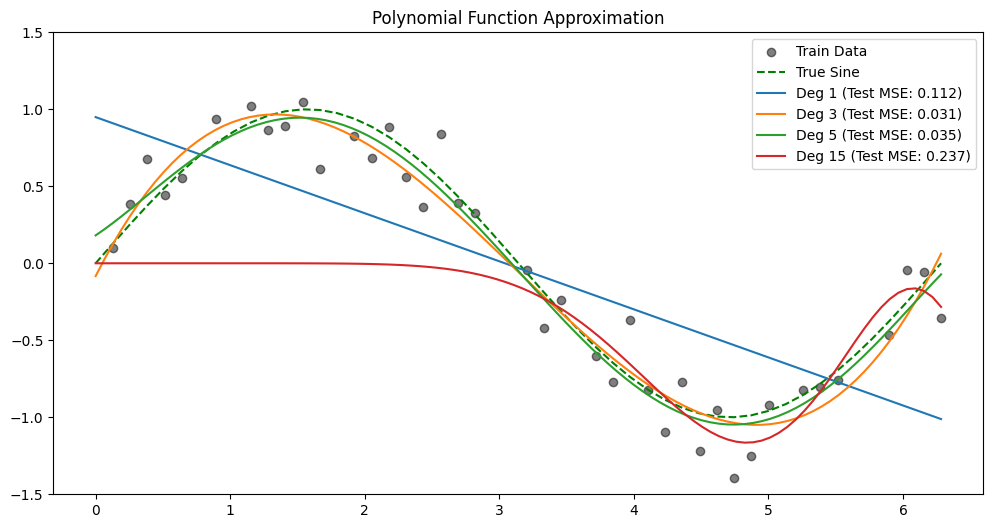

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 50
x = np.linspace(0, 2 * np.pi, n)
y_true = np.sin(x)
y_noisy = y_true + np.random.normal(0, 0.2, n)

#========================================
# Train-Test Split (80-20)
#========================================
idx = np.random.permutation(n)
train_idx, test_idx = idx[:40], idx[40:]
x_train, y_train = x[train_idx], y_noisy[train_idx]
x_test, y_test = x[test_idx], y_noisy[test_idx]

def get_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def fit_polynomial(x, y, degree):
    # Create feature matrix X: [1, x, x^2, ..., x^d]
    X = np.vander(x, degree + 1, increasing=True)
    # Normal Equation: w = (X.T @ X)^-1 @ X.T @ y
    weights = np.linalg.pinv(X.T @ X) @ X.T @ y
    return weights

def predict(x, weights):
    X = np.vander(x, len(weights), increasing=True)
    return X @ weights

#==========================================
# Experiment with different degrees
#==========================================
degrees = [1, 3, 5, 15] # 1 is Linear
plt.figure(figsize=(12, 6))
plt.scatter(x_train, y_train, color='black', alpha=0.5, label='Train Data')
plt.plot(x, y_true, 'g--', label='True Sine')

for d in degrees:
    w = fit_polynomial(x_train, y_train, d)
    y_pred_train = predict(x_train, w)
    y_pred_test = predict(x_test, w)

    train_err = get_mse(y_train, y_pred_train)
    test_err = get_mse(y_test, y_pred_test)

    # Plotting
    x_range = np.linspace(0, 2 * np.pi, 100)
    plt.plot(x_range, predict(x_range, w), label=f'Deg {d} (Test MSE: {test_err:.3f})')
    print(f"Degree {d} | Train MSE: {train_err:.4f} | Test MSE: {test_err:.4f}")

plt.ylim(-1.5, 1.5)
plt.legend()
plt.title("Polynomial Function Approximation")
plt.show()

## Question 11 : Implement a two-layer neural network
---

with 2 input neurons, 10 hidden neurons, and 1 output neuron using ReLU activation in the hidden layer to solve the XOR classification problem. Investigate how the learning rate and bias initialization affect the dying ReLU phenomenon. Weights are initialized as

Wij ∼ N (0, 0.01)

unless stated otherwise.
Tasks
1. Train the network under the following five configurations:
- Case 1: Learning rate = 0.1, Bias initialization = -5.0, Epochs = 500
- Case 2: Learning rate = 0.1, Bias initialization = 0.0, Epochs = 500
- Case 3: Learning rate = 0.01, Bias initialization = -5.0, Epochs = 500
- Case 4: Learning rate = 0.01, Bias initialization = 0.0, Epochs = 500
- Case 5: Learning rate = 0.01, Bias initialization = random, Epochs = 10000

2. For each configuration, plot a grid of figures showing:
- Row 1: Training loss versus epochs
- Row 2: Fraction of dead hidden neurons versus epochs
- Row 3: Classification accuracy versus epochs


3. Answer the following questions:

    (a) Which configurations exhibit dying ReLU behavior? Explain why.

    (b) Why are dead ReLU neurons unable to recover through gradient descent?

In [9]:
class XorClassfication :
    def __init__(self):
        np.random.seed(42)

    # ===============================================
    # 1.Intiliaze Weight and Bias Parameters
    # ===============================================
    def intialize_paramneters(self,bias_initilization):
        input_neuron = 2
        hidden_neuron = 10
        output_neuron = 1
        W1 = np.random.normal(0, 0.01, (input_neuron,hidden_neuron))
        W2 = np.random.normal(0, 0.01, (hidden_neuron,output_neuron))
        if bias_initilization == "random":
            b1 = np.random.normal(0, 0.01, (1,hidden_neuron))
            b2 = np.random.normal(0, 0.01, (1,output_neuron))
        else :
            b1 = np.ones((1,hidden_neuron))* bias_initilization
            b2 = np.ones((1,output_neuron))* bias_initilization
        return W1,W2,b1,b2

    # ===============================================
    # 2.Sigmoid + ReLU Activation + Gradient of Sigmoid + ReLU
    # ===============================================
    def relu_activation(self,z):
        '''max(0,z)'''
        return  np.maximum(0,z)

    def gradient_relu_activation(self,z):
        '''{0,1}'''
        return  np.where(z>0 , 1 ,0)

    def sigmoid_activation(self,z):
        '''z= W⁽¹⁾x + b⁽¹⁾'''
        return 1 / (1 + np.exp(-z))

    def gradient_sigmoid_activation(self,z):
        '''graident(sigmoid(z)) = sigmoid(z)(1-sigmoid(z))'''
        return self.sigmoid_activation(z) * (1 - self.sigmoid_activation(z))

    # ===============================================
    # 5.Forward Pass + Dead Neuron + Accuracy + Compute Loss
    # ===============================================
    def forward_propagation(self,X, y,W1, b1, W2, b2):
        '''Forward Pass'''
        z1 = X @ W1 + b1
        h = self.relu_activation(z1)
        z2 = h @ W2 + b2
        y_hat = self.sigmoid_activation(z2)

        # Dead neuron fraction
        dead = np.mean(np.mean(h == 0, axis=0))

        # Accuracy
        preds = (y_hat > 0.5).astype(int)
        acc = np.mean(preds == y)

        return z1,h,z2,y_hat,dead,acc

    def compute_loss(self,y,y_hat):
        '''BCE - Binary Cross Entropy'''
        loss = -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))
        return loss

    # ===============================================
    # 6.backpropagation
    # ===============================================
    def back_propagation(self,X, y, z1, h,z2, W2,y_hat):

        dz2 = y_hat - y
        dW2 = h.T @ dz2 / len(X)
        db2 = np.mean(dz2, axis=0, keepdims=True)

        dh = dz2 @ W2.T
        dz1 = dh * self.gradient_relu_activation(z1)
        dW1 = X.T @ dz1 / len(X)
        db1 = np.mean(dz1, axis=0, keepdims=True)

        return dW1,db1,dW2,db2

    #==================================================
    # 3. Train Model
    #==================================================
    def train_model(self,X,y,lr,W1,W2,b1,b2,epochs):
        losses = []
        dead_fraction = []
        accuracies = []
        for epoch in range(epochs):
           z1,h,z2,y_hat,dead,acc = self.forward_propagation(X,y,W1,b1,W2,b2) #forward propagation
           loss = self.compute_loss(y,y_hat) #loss computation
           losses.append(loss)
           dead_fraction.append(dead)
           accuracies.append(acc)

           dW1,db1,dW2,db2 = self.back_propagation(X, y, z1,h,z2,W2,y_hat) #backpropagation
           # Update
           W1 -= lr * dW1
           b1 -= lr * db1
           W2 -= lr * dW2
           b2 -= lr * db2
        return losses,dead_fraction,accuracies


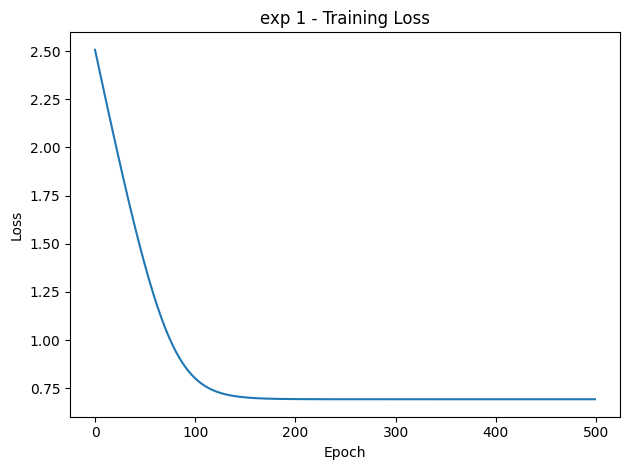

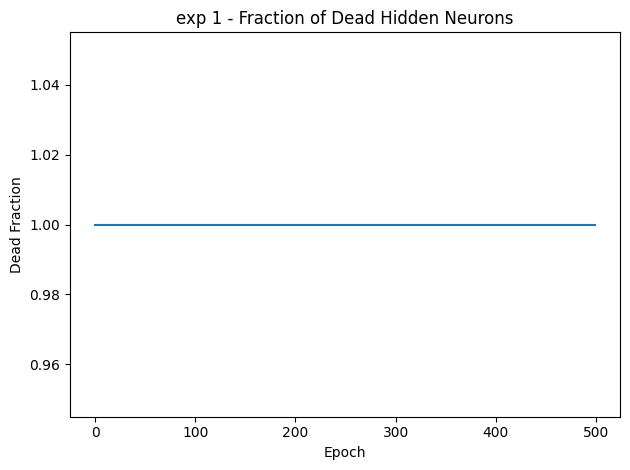

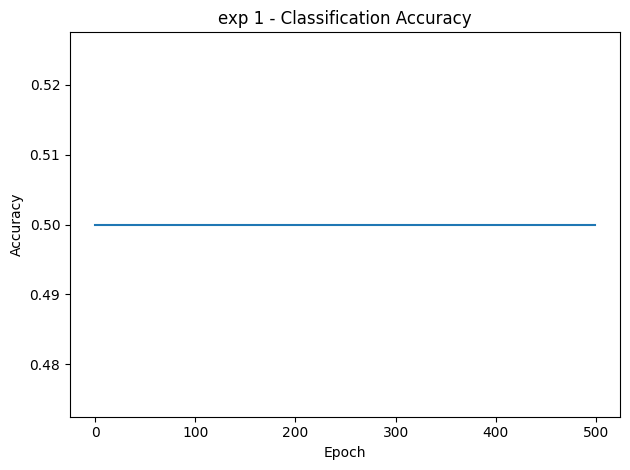

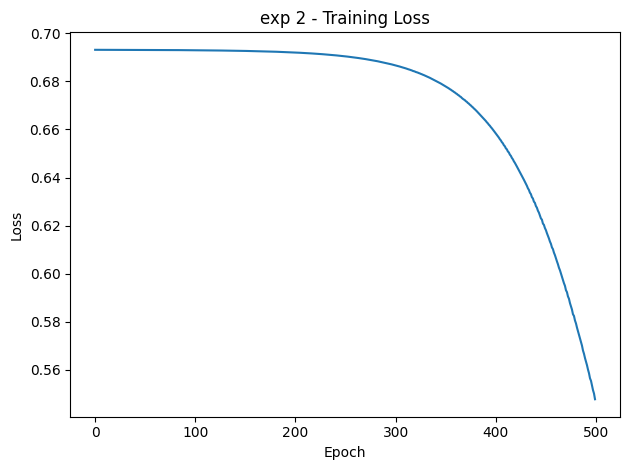

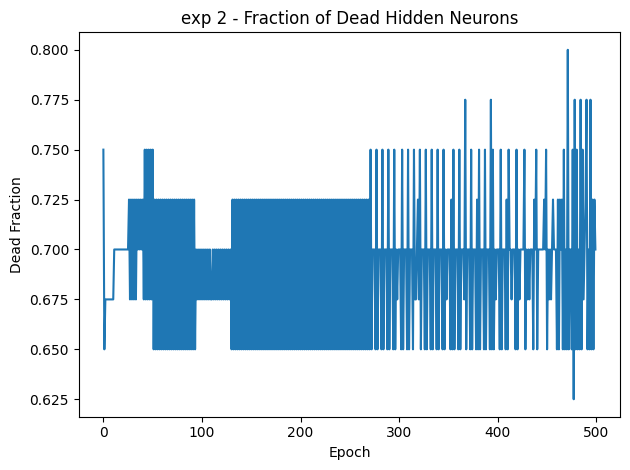

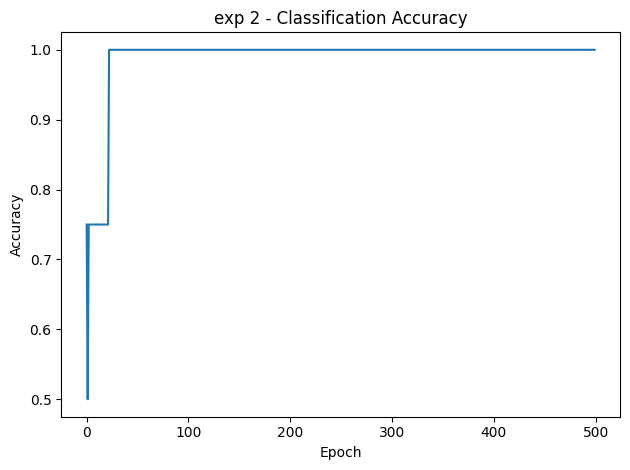

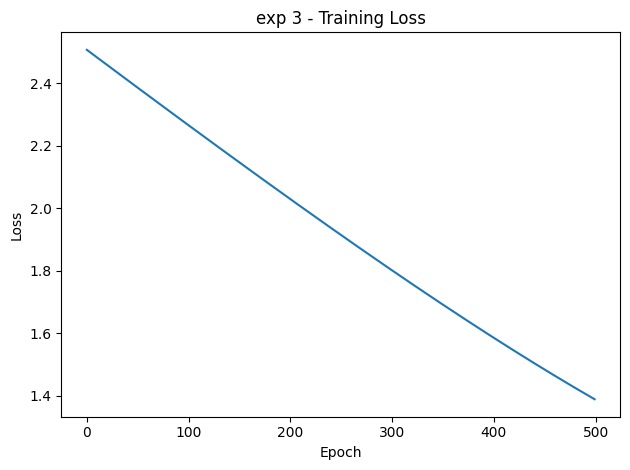

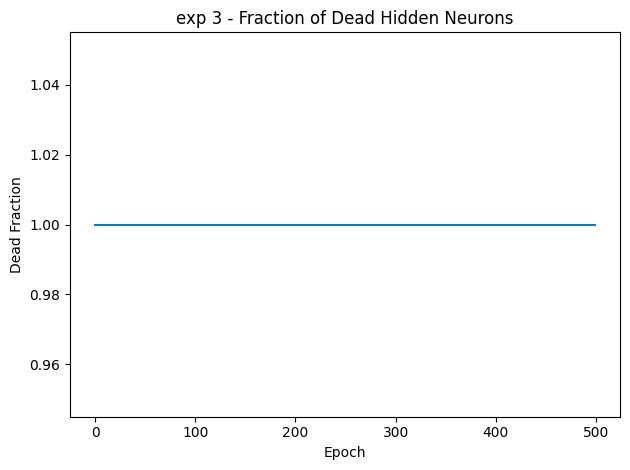

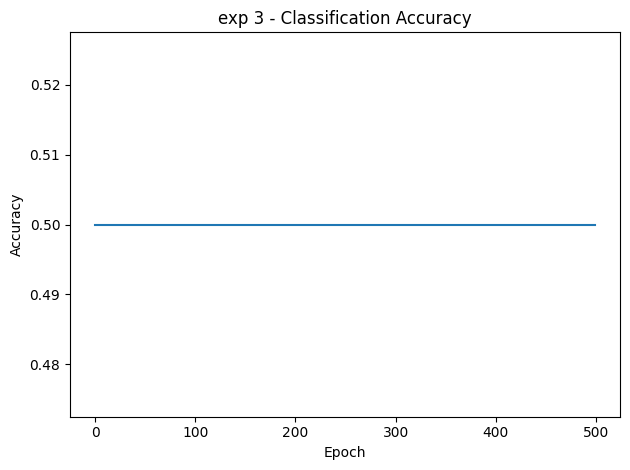

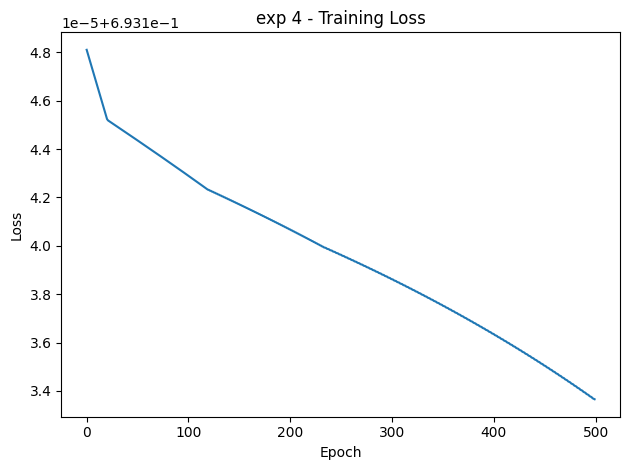

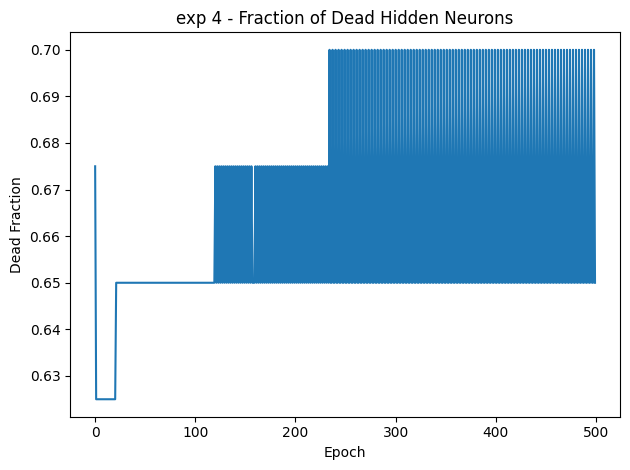

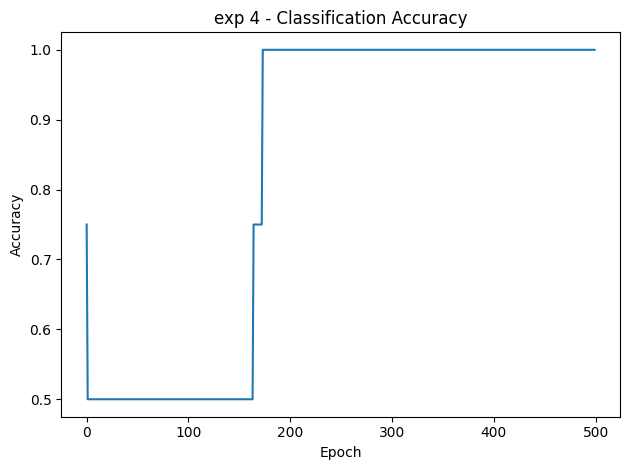

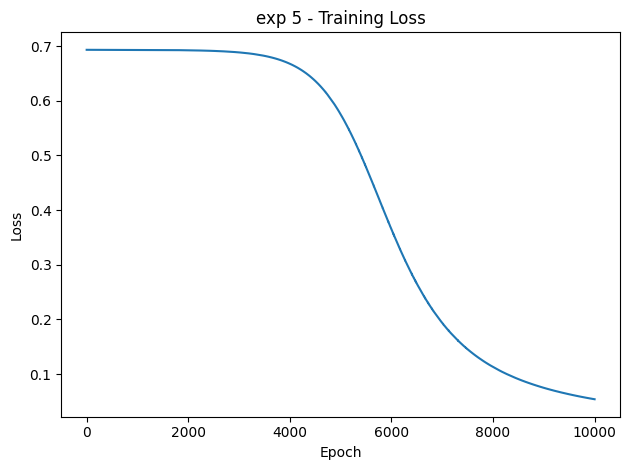

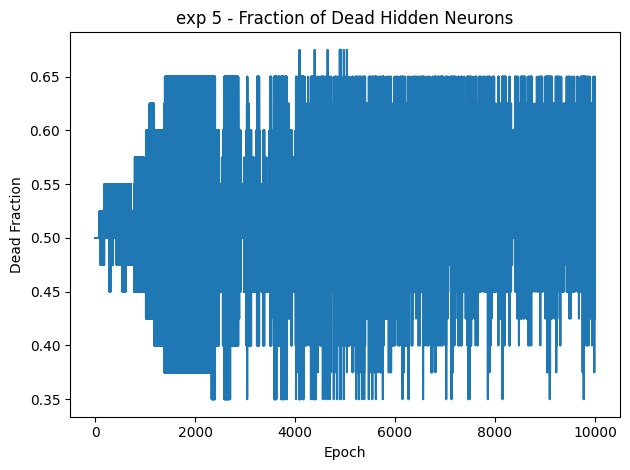

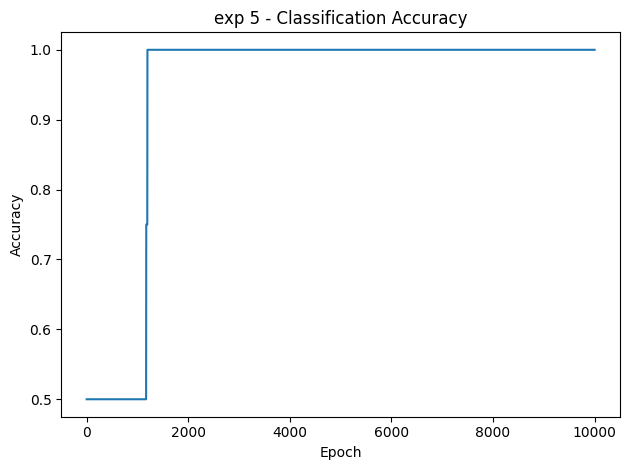

In [10]:
if __name__ == "__main__":
    xor_classification = XorClassfication()

    # XOR dataset
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y = np.array([[0],[1],[1],[0]])

    #training inputs
    experiement = [
    ("exp 1", 0.1, -5.0, 500),
    ("exp 2", 0.1, 0.0, 500),
    ("exp 3", 0.01, -5.0, 500),
    ("exp 4", 0.01, 0.0, 500),
    ("exp 5", 0.01, "random", 10000),]

    results = {}
    #training the model
    for exp, learning_rates , bias_initilizations, epochs in experiement:
        W1,W2,b1,b2 = xor_classification.intialize_paramneters(bias_initilizations)
        results[exp] = xor_classification.train_model(X,y,learning_rates,W1,W2,b1,b2,epochs)

    # Plotting (separate figure per metric per experiment)
    for exp in results:
        losses, dead_fraction, accuracies = results[exp]

        plt.figure()
        plt.plot(losses)
        plt.title(f"{exp} - Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.tight_layout()
        plt.show()

        plt.figure()
        plt.plot(dead_fraction)
        plt.title(f"{exp} - Fraction of Dead Hidden Neurons")
        plt.xlabel("Epoch")
        plt.ylabel("Dead Fraction")
        plt.tight_layout()
        plt.show()

        plt.figure()
        plt.plot(accuracies)
        plt.title(f"{exp} - Classification Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.tight_layout()
        plt.show()
